In [168]:
from dotenv import load_dotenv
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [169]:
SAMPLE_SIZE = 50000

In [170]:
odf = pd.read_csv(r'..\data\raw\dataset.csv')

In [171]:
pdf = pd.read_csv(r'..\data\processed\processed.csv')

In [172]:
pdf.shape

(979591, 5)

In [173]:
pdf.head()

,body,controversiality,upvotes,text_clean,language
0,Your submission has been automatically removed...,0,1,your submission has been automatically removed...,en
1,"Dont squeeze her with you massive hand, you me...",0,19,"dont squeeze her with you massive hand, you me...",en
2,It's pretty well known and it was a paid produ...,0,3,it's pretty well known and it was a paid produ...,en
3,You know we have laws against that currently c...,0,10,you know we have laws against that currently c...,en
4,"Yes, there is a difference between gentle supp...",0,1,"yes, there is a difference between gentle supp...",en


In [174]:
odf.head()

,subreddit,body,controversiality,score
0,gameofthrones,Your submission has been automatically removed...,0,1
1,aww,"Dont squeeze her with you massive hand, you me...",0,19
2,gaming,It's pretty well known and it was a paid produ...,0,3
3,news,You know we have laws against that currently c...,0,10
4,politics,"Yes, there is a difference between gentle supp...",0,1


In [175]:
cdf = pd.merge(pdf, odf, how='inner', on='body')

In [176]:
cdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34980547 entries, 0 to 34980546
Data columns (total 8 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   body                object
 1   controversiality_x  int64 
 2   upvotes             int64 
 3   text_clean          object
 4   language            object
 5   subreddit           object
 6   controversiality_y  int64 
 7   score               int64 
dtypes: int64(4), object(4)
memory usage: 2.1+ GB


In [177]:
cdf.head()

,body,controversiality_x,upvotes,text_clean,language,subreddit,controversiality_y,score
0,Your submission has been automatically removed...,0,1,your submission has been automatically removed...,en,gameofthrones,0,1
1,Your submission has been automatically removed...,0,1,your submission has been automatically removed...,en,gameofthrones,0,1
2,Your submission has been automatically removed...,0,1,your submission has been automatically removed...,en,gameofthrones,0,1
3,Your submission has been automatically removed...,0,1,your submission has been automatically removed...,en,gameofthrones,0,1
4,Your submission has been automatically removed...,0,1,your submission has been automatically removed...,en,gameofthrones,0,1


In [178]:
cdf.isnull().sum()

body                  0
controversiality_x    0
upvotes               0
text_clean            0
language              0
subreddit             0
controversiality_y    0
score                 0
dtype: int64

In [179]:
cdf.sample(5)

,body,controversiality_x,upvotes,text_clean,language,subreddit,controversiality_y,score
6006928,"If this is a dank meme, **Upvote** this commen...",0,1,"if this is a dank meme, **upvote** this commen...",en,dankmemes,0,1
9319474,"If this is a dank meme, **Upvote** this commen...",0,1,"if this is a dank meme, **upvote** this commen...",en,dankmemes,0,1
17147406,"If this is a dank meme, **Upvote** this commen...",0,1,"if this is a dank meme, **upvote** this commen...",en,dankmemes,0,1
34142178,It looks like you've posted a personal perspec...,0,1,it looks like you've posted a personal perspec...,en,Showerthoughts,0,1
12846008,"If this is a dank meme, **Upvote** this commen...",0,1,"if this is a dank meme, **upvote** this commen...",en,dankmemes,0,1


In [180]:
cdf.drop(columns=['body', 'controversiality_y', 'score'], inplace=True)

In [181]:
cdf.head()['text_clean'][0]

'your submission has been automatically removed because all post titles must begin with one hard-bracketed spoiler scope tag, like to find the title scope most appropriate for your post and . *i am a bot, and this action was performed automatically. please if you have any questions or concerns.*'

In [182]:
pcdf = cdf[~cdf['text_clean'].str.contains("your submission has been automatically removed")]

In [183]:
REMOVE_TEXTS = [
    "[removed]", "[deleted]", "[removed by reddit]",
    "[deleted by user]", "[removed by moderators]",
    "", " ", None
]

pcdf = pcdf[~pcdf['text_clean'].isin(REMOVE_TEXTS)]

In [184]:
pcdf.head()

,controversiality_x,upvotes,text_clean,language,subreddit
562,0,19,"dont squeeze her with you massive hand, you me...",en,aww
563,0,3,it's pretty well known and it was a paid produ...,en,gaming
564,0,10,you know we have laws against that currently c...,en,news
565,0,1,"yes, there is a difference between gentle supp...",en,politics
566,0,2,please let this become a meme. i want some dar...,en,dankmemes


In [185]:
pcdf.subreddit.unique()

array(['aww', 'gaming', 'news', 'politics', 'dankmemes',
       'relationship_advice', 'nba', 'worldnews', 'AskReddit',
       'The_Donald', 'AmItheAsshole', 'SquaredCircle', 'gameofthrones',
       'leagueoflegends', 'hockey', 'videos', 'teenagers', 'gonewild',
       'movies', 'funny', 'pics', 'marvelstudios', 'memes', 'soccer',
       'freefolk', 'MortalKombat', 'todayilearned', 'apexlegends',
       'asoiaf', 'Market76', 'Animemes', 'FortNiteBR', 'nfl', 'trashy',
       'unpopularopinion', 'ChapoTrapHouse', 'Showerthoughts', 'RoastMe',
       'wallstreetbets', 'Pikabu'], dtype=object)

In [186]:
pcdf.subreddit.value_counts(ascending=True).describe().round(2)

count          40.00
mean       865011.82
std       4555358.91
min         24770.00
25%         25877.00
50%         28975.00
75%         71321.25
max      28894761.00
Name: count, dtype: float64

In [187]:
pcdf.subreddit.value_counts(normalize=True, ascending=True) * 100

subreddit
SquaredCircle           0.071589
news                    0.071635
nba                     0.072060
worldnews               0.072802
nfl                     0.073077
hockey                  0.073276
relationship_advice     0.073638
trashy                  0.074505
Pikabu                  0.074635
movies                  0.074745
MortalKombat            0.074802
marvelstudios           0.075366
wallstreetbets          0.076626
The_Donald              0.076641
aww                     0.076973
videos                  0.078010
ChapoTrapHouse          0.079091
gaming                  0.080242
gonewild                0.081811
todayilearned           0.083233
AskReddit               0.084250
pics                    0.085158
soccer                  0.086779
Animemes                0.087192
freefolk                0.088401
Market76                0.090770
apexlegends             0.107883
teenagers               0.112149
RoastMe                 0.134264
funny                   0.181743


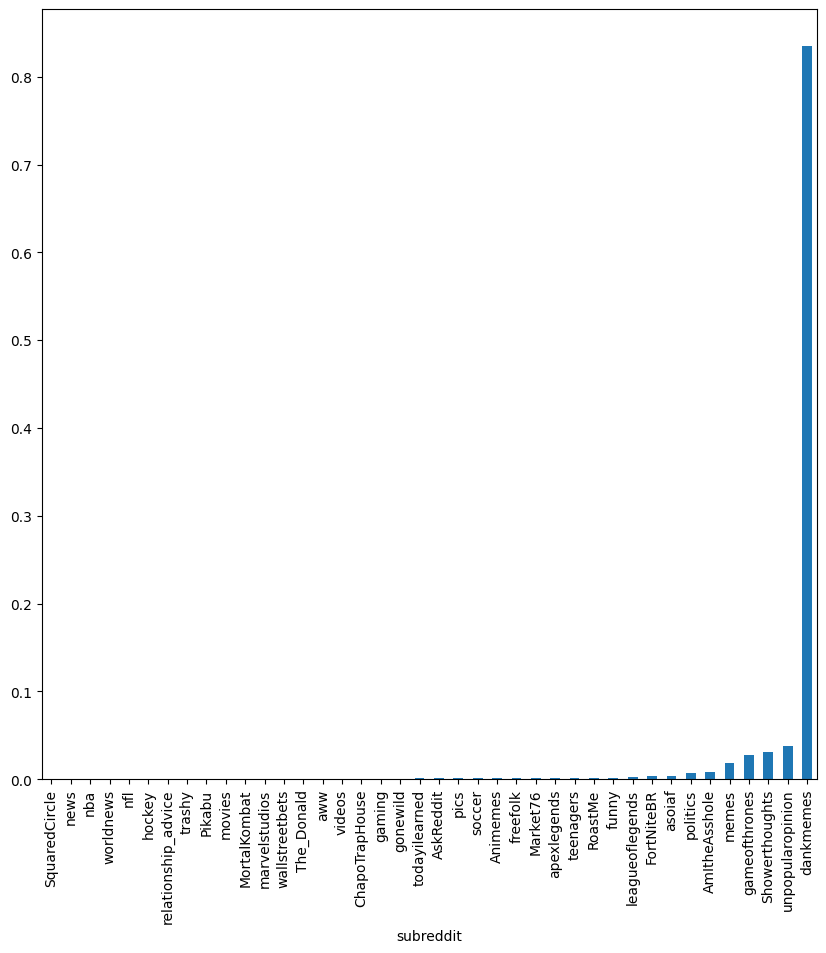

In [188]:
plt.figure(figsize=(10, 10))
pcdf.subreddit.value_counts(normalize=True, ascending=True).plot(kind='bar')
plt.show()

In [231]:
random_state = 10
dnkmems = pcdf[pcdf.subreddit == 'dankmemes'].sample(25000, random_state=random_state)
unpop = pcdf[pcdf.subreddit == 'unpopularopinion'].sample(25000, random_state=random_state)
shwrth = pcdf[pcdf.subreddit == 'Showerthoughts'].sample(25000, random_state=random_state)
gt = pcdf[pcdf.subreddit == 'gameofthrones'].sample(25000, random_state=random_state)
mems = pcdf[pcdf.subreddit == 'memes'].sample(25000, random_state=random_state)
assih = pcdf[pcdf.subreddit == 'AmItheAsshole'].sample(25000, random_state=random_state)
plot = pcdf[pcdf.subreddit == 'politics'].sample(25000, random_state=random_state)
aso = pcdf[pcdf.subreddit == 'asoiaf'].sample(25000, random_state=random_state)
fort = pcdf[pcdf.subreddit == 'FortNiteBR'].sample(25000, random_state=random_state)
llg = pcdf[pcdf.subreddit == 'leagueoflegends'].sample(25000, random_state=random_state)
funny = pcdf[pcdf.subreddit == 'funny'].sample(25000, random_state=random_state)
oth = pcdf[~(pcdf.subreddit.isin(['dankmemes', 'unpopularopinion', 'Showerthoughts', 'gameofthrones', 'memes', 'AmItheAsshole', 'politics', 'asoiaf', 'FortNiteBR', 'leagueoflegends', 'funny']))]


In [232]:
bdf = pd.concat([dnkmems, unpop, shwrth, gt, mems, assih, plot, aso, fort, llg, funny, oth])

<Axes: xlabel='subreddit'>

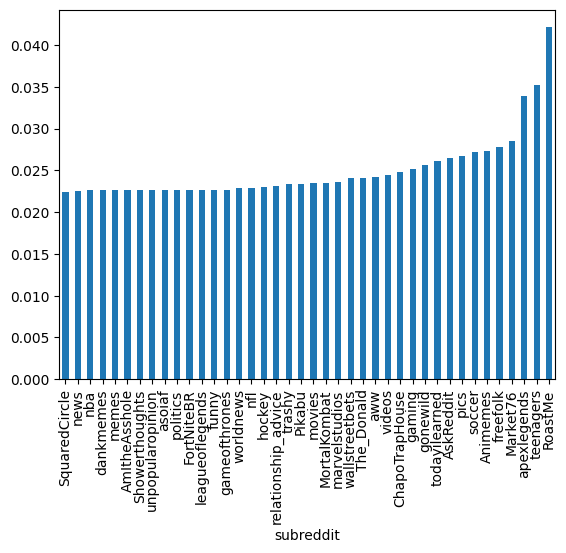

In [233]:
bdf.subreddit.value_counts(normalize=True, ascending=True).plot(kind='bar')

In [234]:
bdf.controversiality_x.value_counts()

controversiality_x
0    1079288
1      23218
Name: count, dtype: int64

<Axes: xlabel='controversiality_x'>

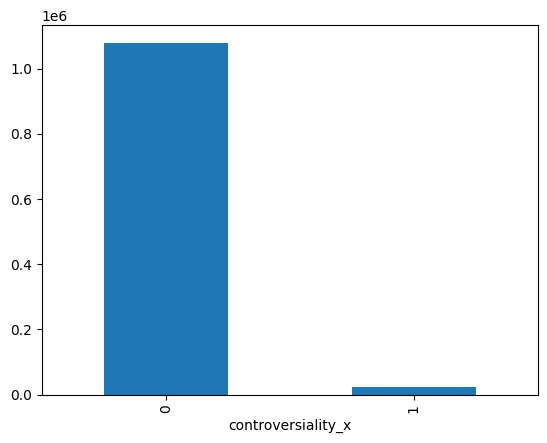

In [235]:
bdf.controversiality_x.value_counts().plot(kind='bar')

In [236]:
final_sample = bdf.sample(20000, random_state=random_state)

In [237]:
final_sample.controversiality_x.value_counts(normalize=True) * 100

controversiality_x
0    97.75
1     2.25
Name: proportion, dtype: float64

In [238]:
odf.controversiality.value_counts(normalize=True) * 100

controversiality
0    97.0417
1     2.9583
Name: proportion, dtype: float64

In [240]:
final_sample.to_csv(r'../data/interim/data.csv', index=False)